# 🔥 Notebook 03 — Fine-tuning Completo

**Objetivo:** Superar el baseline descongelando gradualmente el backbone.

**Estrategia:**
1. Cargar el checkpoint `baseline.pt`
2. Descongelar los últimos 3 bloques de EfficientNet-B0
3. Usar **learning rates diferenciales**: backbone lr bajo (1e-4), cabeza lr alto (1e-3)
4. Scheduler `CosineAnnealingLR` para decaer el lr suavemente
5. Early stopping con paciencia de 5 épocas

**Meta:** Top-1 > 80%, Top-5 > 92%


In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import datasets
from torch.utils.data import DataLoader

from src.config import (
    DATA_DIR, WEIGHTS_DIR, DEVICE, SEED, BATCH_SIZE, FOOD101_CLASSES,
    FINETUNE_BACKBONE_LR, FINETUNE_HEAD_LR, FINETUNE_WEIGHT_DECAY,
    FINETUNE_EPOCHS, EARLY_STOP_PATIENCE, LABEL_SMOOTHING
)
from src.model import load_model, unfreeze_last_blocks, get_param_groups
from src.trainer import train_model
from src.transforms import get_train_transform, get_val_transform
from src.utils import plot_training_curves

torch.manual_seed(SEED)
print(f'Device: {DEVICE}')

Device: mps


## 📁 Parte 1 — DataLoaders


In [2]:
train_loader = DataLoader(
    datasets.Food101(str(DATA_DIR), split='train', transform=get_train_transform(), download=False),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    datasets.Food101(str(DATA_DIR), split='test', transform=get_val_transform(), download=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)
print(f'Train: {len(train_loader.dataset):,} | Val: {len(val_loader.dataset):,}')

Train: 75,750 | Val: 25,250


## 🧠 Parte 2 — Cargar Baseline y Descongelar Backbone


In [3]:
baseline_path = WEIGHTS_DIR / 'baseline.pt'
assert baseline_path.exists(), f'Primero correr 02_baseline.ipynb — no se encontró {baseline_path}'

model = load_model(baseline_path, backbone='efficientnet_b0', device=DEVICE)

# Descongelar los últimos 3 bloques de features + classifier
# EfficientNet-B0: features[0..8] → dejamos libres features[6], [7], [8]
unfreeze_last_blocks(model, n_blocks=3, backbone='efficientnet_b0')

total      = sum(p.numel() for p in model.parameters())
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')

Parámetros entrenables: 3,285,121 / 4,136,929 (79.4%)


## 🏋️ Parte 3 — Optimizador con Learning Rates Diferenciales

La idea es que las capas del backbone ya tienen representaciones útiles:
un lr muy alto las destruiría. La cabeza, en cambio, necesita aprender desde cero.


In [4]:
param_groups = get_param_groups(
    model,
    backbone_lr=FINETUNE_BACKBONE_LR,  # 1e-4
    head_lr=FINETUNE_HEAD_LR,          # 1e-3
    backbone='efficientnet_b0'
)

optimizer = torch.optim.AdamW(param_groups, weight_decay=FINETUNE_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

print(f'Optimizer: AdamW  backbone_lr={FINETUNE_BACKBONE_LR}  head_lr={FINETUNE_HEAD_LR}')
print(f'Scheduler: CosineAnnealingLR  T_max={FINETUNE_EPOCHS}')
print(f'Early stopping: paciencia={EARLY_STOP_PATIENCE} épocas')

Optimizer: AdamW  backbone_lr=0.0001  head_lr=0.001
Scheduler: CosineAnnealingLR  T_max=25
Early stopping: paciencia=5 épocas


## 🚀 Parte 4 — Entrenamiento


In [5]:
save_path = WEIGHTS_DIR / 'model_v1.pt'

history = train_model(
    model, train_loader, val_loader,
    epochs=FINETUNE_EPOCHS,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    device=DEVICE,
    save_path=save_path,
    patience=EARLY_STOP_PATIENCE,
)


Época 1/25


  train:   0%|          | 0/1184 [00:00<?, ?it/s]/Users/nicok/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  train loss=2.4788  acc=0.520  |  val loss=1.8160  top1=0.716  top5=0.915
  ✓ Guardado en /Users/nicok/Documents/MIA/Vision por computadora/TP Final/notebooks/../weights/model_v1.pt  (top1=0.716)

Época 2/25


  train loss=2.1612  acc=0.607  |  val loss=1.6913  top1=0.753  top5=0.931
  ✓ Guardado en /Users/nicok/Documents/MIA/Vision por computadora/TP Final/notebooks/../weights/model_v1.pt  (top1=0.753)

Época 3/25


  train loss=2.0135  acc=0.651  |  val loss=1.6171  top1=0.774  top5=0.939
  ✓ Guardado en /Users/nicok/Documents/MIA/Vision por computadora/TP Final/notebooks/../weights/model_v1.pt  (top1=0.774)

Época 4/25


...

  train loss=1.3730  acc=0.850  |  val loss=1.4231  top1=0.826  top5=0.958

Época 22/25


  train loss=1.3680  acc=0.851  |  val loss=1.4182  top1=0.828  top5=0.958
  ✓ Guardado en /Users/nicok/Documents/MIA/Vision por computadora/TP Final/notebooks/../weights/model_v1.pt  (top1=0.828)

Época 23/25


  train loss=1.3638  acc=0.854  |  val loss=1.4202  top1=0.829  top5=0.958
  ✓ Guardado en /Users/nicok/Documents/MIA/Vision por computadora/TP Final/notebooks/../weights/model_v1.pt  (top1=0.829)

Época 24/25


  train loss=1.3660  acc=0.852  |  val loss=1.4194  top1=0.827  top5=0.958

Época 25/25


  train loss=1.3590  acc=0.855  |  val loss=1.4178  top1=0.827  top5=0.958

Entrenamiento finalizado. Mejor val_top1: 0.829


## 📈 Parte 5 — Curvas y Comparativa con Baseline


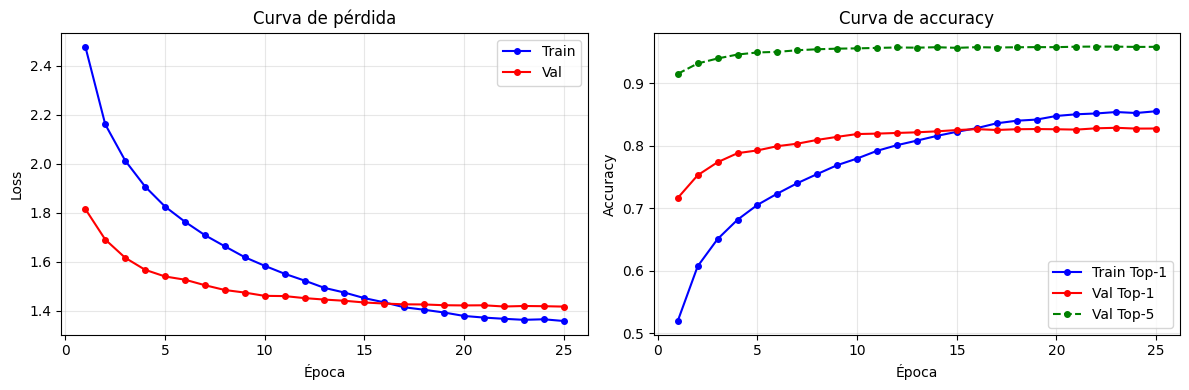


=== Mejor época: 23 ===
Val Top-1: 0.8286 (82.86%)
Val Top-5: 0.9584 (95.84%)

Meta Top-1 > 80%: ✓
Modelo guardado en: /Users/nicok/Documents/MIA/Vision por computadora/TP Final/notebooks/../weights/model_v1.pt


In [6]:
fig = plot_training_curves(history)
plt.show()

best_top1 = max(history['val_top1'])
best_top5 = max(history['val_top5'])
best_epoch = history['val_top1'].index(best_top1) + 1

print(f'\n=== Mejor época: {best_epoch} ===')
print(f'Val Top-1: {best_top1:.4f} ({best_top1*100:.2f}%)')
print(f'Val Top-5: {best_top5:.4f} ({best_top5*100:.2f}%)')
print(f'\nMeta Top-1 > 80%: {"✓" if best_top1 > 0.80 else "✗ (seguir entrenando)"}')
print(f'Modelo guardado en: {save_path}')

---
## ❓ Preguntas de reflexión

1. **¿Cuánto mejoró el fine-tuning respecto al baseline?**
2. **¿En qué época se activó el early stopping?** ¿Había signos de overfitting antes?
3. **¿El scheduler CosineAnnealingLR** ayudó a estabilizar el entrenamiento?
4. **¿Qué pasaría si descongeláramos más bloques** (n_blocks=6 o todo el backbone)?
5. **¿Vale la pena** intentar ResNet50 como comparativa para el informe?
